<a href="https://colab.research.google.com/github/omarhashem80/us-domestic-flights-delay-prediction/blob/main/Flight_Delays_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
usdot_flight_delays_path = kagglehub.dataset_download('usdot/flight-delays')

print('Data source import complete.')


# ✈️ Flight Delay & Cancellation Analytics Platform
### Big Data Project — 2015 U.S. Flight Dataset (DOT / Kaggle)

> **Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)  
> **Size:** ~5.8 million records · 31 features  
> **Tools:** PySpark · Pandas · Scikit-learn · MLlib · Matplotlib · Seaborn · MLxtend

---

## 1. 📌 Introduction & Business Understanding

### 1.1 Problem Statement

The aviation industry faces significant operational and financial challenges due to flight delays and cancellations. These disruptions affect airlines, airports, and passengers, leading to increased operational costs, poor customer satisfaction, and inefficient resource utilization.

This project builds a **data-driven analytics platform** that:
- Predicts whether a flight will be delayed
- Estimates the expected delay duration
- Discovers co-occurring delay patterns
- Segments airports by delay behavior

### 1.2 Business Impact

| Stakeholder | Problem | Platform Benefit |
|---|---|---|
| Airline Ops | Unpredictable delays cause fuel & crew waste | Proactive scheduling adjustments |
| Airport Staff | Congestion hotspots unknown | Identify high-risk windows & routes |
| Booking Platforms | Passengers uninformed | Real-time delay probability scores |
| Revenue Management | Compensation costs | Minimize disruption-driven payouts |

Flight delays cost the U.S. aviation industry **~$28 billion annually** in direct and indirect costs.

### 1.3 Objectives

1. **Delay Prediction (Classification):** Predict whether a flight will be delayed (binary)
2. **Cancellation Prediction:** Identify flights at risk of cancellation
3. **Delay Duration Estimation (Regression):** Predict delay duration in minutes
4. **Pattern Discovery:** FP-Growth for co-occurring delay causes; K-Means airport clustering
5. **MapReduce KNN:** Distributed KNN implementation in pseudo-distributed Hadoop mode

### 1.4 Success Metrics

**Classification:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Regression:** RMSE, MAE, R²  
**Business:** Delay uncertainty reduction, scheduling efficiency improvement

---
## 2. 📂 Dataset Description

### 2.1 Data Source

- **Source:** U.S. Department of Transportation (RITA/BTS)
- **Platform:** [Kaggle – 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)
- **Files:** `flights.csv` (primary), `airlines.csv`, `airports.csv`
- **Year:** 2015 (full calendar year)

### 2.2 Dataset Overview

| Property | Value |
|---|---|
| Records | ~5.8 million |
| Features | 31 columns |
| Airlines | 14 major U.S. carriers |
| Airports | 322 origin airports |
| File Size | ~574 MB (flights.csv) |

This qualifies as **Big Data** — exceeding typical in-memory Pandas capacity.

### 2.3 Data Dictionary

| Column | Type | Description |
|---|---|---|
| YEAR / MONTH / DAY | int | Flight date components |
| DAY_OF_WEEK | int | 1=Monday … 7=Sunday |
| AIRLINE | str | IATA airline code |
| FLIGHT_NUMBER | int | Carrier flight number |
| TAIL_NUMBER | str | Aircraft registration |
| ORIGIN_AIRPORT | str | Departure airport IATA |
| DESTINATION_AIRPORT | str | Arrival airport IATA |
| SCHEDULED_DEPARTURE | int | HHMM scheduled departure |
| DEPARTURE_TIME | float | Actual departure (HHMM) |
| DEPARTURE_DELAY | float | Delay in minutes (neg=early) |
| TAXI_OUT | float | Taxi-out time (min) |
| WHEELS_OFF | float | Wheels-off time |
| SCHEDULED_TIME | float | Planned flight duration |
| ELAPSED_TIME | float | Actual flight duration |
| AIR_TIME | float | Airborne time |
| DISTANCE | int | Distance in miles |
| WHEELS_ON | float | Wheels-on time |
| TAXI_IN | float | Taxi-in time |
| SCHEDULED_ARRIVAL | int | HHMM scheduled arrival |
| ARRIVAL_TIME | float | Actual arrival |
| ARRIVAL_DELAY | float | Arrival delay (target) |
| DIVERTED | int | 1=diverted |
| CANCELLED | int | 1=cancelled |
| CANCELLATION_REASON | str | A/B/C/D |
| AIR_SYSTEM_DELAY | float | Delay from ATC |
| SECURITY_DELAY | float | Delay from security |
| AIRLINE_DELAY | float | Delay from airline |
| LATE_AIRCRAFT_DELAY | float | Delay from late aircraft |
| WEATHER_DELAY | float | Delay from weather |

### 2.4 Big Data Considerations

- Full dataset (~574 MB) exceeds comfortable Pandas RAM usage
- **PySpark** used for distributed processing
- **Pandas** used on sampled subsets for EDA visualizations
- Memory partitioning and caching strategies applied

---
## 3. ⚙️ Environment Setup & Libraries

### 3.1 Import Libraries

In [ ]:
import os
import sys
import warnings
import logging

# Suppress Python warnings
warnings.filterwarnings("ignore")

# Suppress logging noise
logging.getLogger().setLevel(logging.ERROR)

# LAST RESORT: silence stderr spam
sys.stderr = open(os.devnull, 'w')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/02 09:22:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-05-02 09:35:53,427 INFO XGBoost-PySpark: _train_booster Training on CPUs
[09:35:54] Task 1 got rank 1
[09:35:54] Task 2 got rank 2
[09:35:54] Task 0 got rank 0
[09:35:54] Task 3 got rank 3
[09:36:03] [0]	training-auc:0.92712
[09:36:03] [1]	training-auc:0.91247
[09:36:04] [2]	training-auc:0.95054
[09:36:04] [3]	training-auc:0.95301
[09:36:05] [4]	training-auc:0.95543
[09:36:05] [5]	training-auc:0.95682
[09:36:06] [6]	training-auc:0.95768
[09:36:06] [7]	training-auc:0.95830
[09:36:07] [8]	training-auc:0.95896
[09:36:08] [9]	training-auc:0.95938
[09:36:08] [10]	training-auc:0.95979
[09:36:09] [11]	training-auc:0.96015
[09:36:09] [12]	tr

In [ ]:
import os
import sys
import time
import warnings
import math
import json
from collections import defaultdict, Counter
from itertools import combinations
import os
import warnings
import logging

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.ui.showConsoleProgress=false pyspark-shell"

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)
logging.getLogger("py.warnings").setLevel(logging.ERROR)
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

sns.set_palette('husl')
PALETTE = sns.color_palette('husl', 14)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, FloatType, DoubleType
)
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler as SparkStandardScaler,
    StringIndexer,
    OneHotEncoder
)

from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    RandomForestClassifier as SparkRF,
    GBTClassifier
)

from pyspark.ml.regression import (
    LinearRegression as SparkLinReg,
    RandomForestRegressor as SparkRFReg,
    GBTRegressor
)

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator
)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.fpm import FPGrowth

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.cluster import KMeans

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

### 3.2 Configuration

In [ ]:
LOCAL_DATA_PATH = "data/"
KAGGLE_DATA_PATH = "/kaggle/input/datasets/organizations/usdot/flight-delays"

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = KAGGLE_DATA_PATH
FLIGHTS_PATH = os.path.join(DATA_DIR, 'flights.csv')
AIRLINES_PATH = os.path.join(DATA_DIR, 'airlines.csv')
AIRPORTS_PATH = os.path.join(DATA_DIR, 'airports.csv')

SAMPLE_FRAC = 0.05
PANDAS_CHUNKSIZE = 500_000

TEST_SIZE = 0.2
DELAY_THRESHOLD = 15

spark = (
    SparkSession.builder
    .appName('FlightDelayAnalytics')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.default.parallelism', '8')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

print(f'Master: {spark.sparkContext.master}')
print(f'App: {spark.sparkContext.appName}')

Master: local[*]
App: FlightDelayAnalytics


---
## 4. 📥 Data Loading & Initial Inspection

### 4.1 Load Dataset

In [ ]:
sdf = spark.read.option('header', 'true').option('inferSchema', 'true').option('nullValue', '').csv(FLIGHTS_PATH)

airlines_df  = pd.read_csv(AIRLINES_PATH)
airports_df  = pd.read_csv(AIRPORTS_PATH)

pdf_sample = sdf.sample(fraction=SAMPLE_FRAC, seed=RANDOM_SEED).toPandas()
print(f'total data: {sdf.count()}')
print(f'sample data: {pdf_sample.shape[0]}')

total data: 5819079
sample data: 290686


### 4.2 Schema & Data Types

In [ ]:
sdf.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable = true)
 |-- ARRIVAL_DELAY: integer (null

In [ ]:
pdf_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 290686 non-null  int32  
 1   MONTH                290686 non-null  int32  
 2   DAY                  290686 non-null  int32  
 3   DAY_OF_WEEK          290686 non-null  int32  
 4   AIRLINE              290686 non-null  object 
 5   FLIGHT_NUMBER        290686 non-null  int32  
 6   TAIL_NUMBER          289952 non-null  object 
 7   ORIGIN_AIRPORT       290686 non-null  object 
 8   DESTINATION_AIRPORT  290686 non-null  object 
 9   SCHEDULED_DEPARTURE  290686 non-null  int32  
 10  DEPARTURE_TIME       286462 non-null  float64
 11  DEPARTURE_DELAY      286462 non-null  float64
 12  TAXI_OUT             286329 non-null  float64
 13  WHEELS_OFF           286329 non-null  float64
 14  SCHEDULED_TIME       290686 non-null  int32  
 15  ELAPSED_TIME     

### 4.3 Initial Preview

In [ ]:
pdf_sample.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,DL,1560,N3743H,ANC,SEA,45,...,451.0,-24.0,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,OO,7370,N432SW,BJI,MSP,520,...,629.0,9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,OO,5460,N583SW,RDD,SFO,530,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,B6,1012,N375JB,ORD,BOS,540,...,823.0,-33.0,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,EV,3268,N14998,ATL,IAD,540,...,739.0,14.0,0,0,None,NaN,NaN,NaN,NaN,NaN


In [ ]:
pdf_sample.describe().round(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,290686.0,290686.00,290686.00,290686.00,290686.00,290686.00,286462.00,286462.00,286329.00,286329.00,...,290686.00,286144.00,285538.00,290686.00,290686.00,53088.00,53088.00,53088.00,53088.00,53088.00
mean,2015.0,6.52,15.71,3.93,2170.33,1329.81,1335.45,9.33,16.05,1357.21,...,1493.90,1476.86,4.36,0.00,0.02,13.53,0.06,18.66,23.45,2.97
std,0.0,3.41,8.79,1.99,1754.89,483.68,496.31,36.41,8.86,497.88,...,507.42,526.29,38.73,0.05,0.12,27.97,2.50,45.77,43.73,20.34
min,2015.0,1.00,1.00,1.00,1.00,3.00,1.00,-43.00,1.00,1.00,...,1.00,1.00,-81.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2015.0,4.00,8.00,2.00,730.00,917.00,921.00,-5.00,11.00,935.00,...,1110.00,1059.00,-13.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2015.0,7.00,16.00,4.00,1688.00,1325.00,1331.00,-2.00,14.00,1343.00,...,1520.00,1513.00,-5.00,0.00,0.00,2.00,0.00,2.00,3.00,0.00
75%,2015.0,9.00,23.00,6.00,3218.00,1730.00,1739.00,7.00,19.00,1753.00,...,1918.00,1917.00,8.00,0.00,0.00,18.00,0.00,19.00,29.00,0.00
max,2015.0,12.00,31.00,7.00,7438.00,2359.00,2400.00,1179.00,171.00,2400.00,...,2400.00,2400.00,1212.00,1.00,1.00,855.00,440.00,1170.00,1174.00,905.00


---
## 5. 🧹 Data Cleaning

### 5.1 Handling Missing Values

In [ ]:
missing = pdf_sample.isnull().sum()
missing_pct = (missing / len(pdf_sample) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
mv_df

,Missing Count,Missing %
CANCELLATION_REASON,286290,98.49
AIR_SYSTEM_DELAY,237598,81.74
SECURITY_DELAY,237598,81.74
WEATHER_DELAY,237598,81.74
AIRLINE_DELAY,237598,81.74
LATE_AIRCRAFT_DELAY,237598,81.74
ARRIVAL_DELAY,5148,1.77
AIR_TIME,5148,1.77
ELAPSED_TIME,5148,1.77
WHEELS_ON,4542,1.56


In [ ]:
total_rows = sdf.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [ ]:
pdf_clean = pdf_sample.copy()

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
pdf_clean[delay_cols] = pdf_clean[delay_cols].fillna(0)

delay_delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
pdf_clean[delay_delay_cols] = pdf_clean[delay_delay_cols].fillna(0)

pdf_clean['CANCELLATION_REASON'] = pdf_clean['CANCELLATION_REASON'].fillna('N')
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN','WHEELS_OFF', 'WHEELS_ON']

for col in time_cols:
    pdf_clean[col] = pdf_clean[col].fillna(0)

sdf_clean = sdf

for col in delay_cols + delay_delay_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

sdf_clean = sdf_clean.fillna({'CANCELLATION_REASON': 'N'})

for col in time_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

In [ ]:
pdf_clean.isna().mean() * 100

YEAR                   0.000000
MONTH                  0.000000
DAY                    0.000000
DAY_OF_WEEK            0.000000
AIRLINE                0.000000
FLIGHT_NUMBER          0.000000
TAIL_NUMBER            0.252506
ORIGIN_AIRPORT         0.000000
DESTINATION_AIRPORT    0.000000
SCHEDULED_DEPARTURE    0.000000
DEPARTURE_TIME         1.453114
DEPARTURE_DELAY        0.000000
TAXI_OUT               0.000000
WHEELS_OFF             0.000000
SCHEDULED_TIME         0.000000
ELAPSED_TIME           0.000000
AIR_TIME               0.000000
DISTANCE               0.000000
WHEELS_ON              0.000000
TAXI_IN                0.000000
SCHEDULED_ARRIVAL      0.000000
ARRIVAL_TIME           1.562511
ARRIVAL_DELAY          0.000000
DIVERTED               0.000000
CANCELLED              0.000000
CANCELLATION_REASON    0.000000
AIR_SYSTEM_DELAY       0.000000
SECURITY_DELAY         0.000000
AIRLINE_DELAY          0.000000
LATE_AIRCRAFT_DELAY    0.000000
WEATHER_DELAY          0.000000
dtype: f

In [ ]:
total_rows = sdf_clean.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf_clean.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
ARRIVAL_TIME,92513,1.59
DEPARTURE_TIME,86153,1.48
TAIL_NUMBER,14721,0.25
SCHEDULED_TIME,6,0.00


### 5.2 Removing Irrelevant Features

In [ ]:
for col in pdf_clean.select_dtypes(include='object').columns:
  print(pdf_clean[col].value_counts(normalize=True) * 100,"*"*50,sep='\n')

AIRLINE
WN    21.651542
DL    15.108399
AA    12.428875
OO    10.127767
EV     9.773088
UA     8.954336
MQ     5.052875
B6     4.569880
US     3.387160
AS     2.966087
NK     2.031402
F9     1.569735
HA     1.320325
VX     1.058531
Name: proportion, dtype: float64
**************************************************
TAIL_NUMBER
N488HA    0.071046
N484HA    0.069322
N491HA    0.064149
N489HA    0.063459
N486HA    0.061734
            ...   
N184DN    0.000345
N662NK    0.000345
N7LJAA    0.000345
N7833A    0.000345
N7LKAA    0.000345
Name: proportion, Length: 4742, dtype: float64
**************************************************
ORIGIN_AIRPORT
ATL      5.922886
ORD      4.847155
DFW      4.066587
DEN      3.390600
LAX      3.345878
           ...   
13873    0.000344
14487    0.000344
10581    0.000344
11111    0.000344
11447    0.000344
Name: proportion, Length: 623, dtype: float64
**************************************************
DESTINATION_AIRPORT
ATL      6.008889
ORD      4.988888

In [ ]:
pdf_sample.FLIGHT_NUMBER.value_counts(normalize=True) * 100

FLIGHT_NUMBER
469     0.068459
326     0.063643
327     0.063299
667     0.062611
761     0.062267
          ...   
6551    0.000344
6719    0.000344
5856    0.000344
5750    0.000344
5752    0.000344
Name: proportion, Length: 6562, dtype: float64

In [ ]:
# Columns to drop:
#   TAIL_NUMBER  — high cardinality, no predictive value
#   YEAR         — constant (2015)
# NOTE: FLIGHT_NUMBER is KEPT — it is in the approved pre-takeoff feature set.

DROP_COLS = ['TAIL_NUMBER', 'YEAR']

pdf_clean = pdf_clean.drop(columns=DROP_COLS)
sdf_clean = sdf_clean.drop(*DROP_COLS)

print(f'Dropped columns: {DROP_COLS}')
print(f'Remaining columns: {pdf_clean.shape[1]}')


Dropped columns: ['TAIL_NUMBER', 'YEAR']
Remaining columns: 29


In [ ]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='object')

In [ ]:
pdf_check = pdf_clean.copy()

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Sum of delay breakdowns (treat NaN as 0 because "no recorded delay component")
pdf_check['BREAKDOWN_SUM'] = pdf_check[delay_cols].fillna(0).sum(axis=1)

# Difference vs actual arrival delay
pdf_check['DIFF'] = pdf_check['ARRIVAL_DELAY'] - pdf_check['BREAKDOWN_SUM']

In [ ]:
pdf_check['DIFF'].describe()

count    290686.000000
mean         -6.436626
std          10.192256
min         -81.000000
25%         -13.000000
50%          -5.000000
75%           0.000000
max          14.000000
Name: DIFF, dtype: float64

### 5.3 Fixing Data Types

In [ ]:
pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                290686 non-null  int32  
 1   DAY                  290686 non-null  int32  
 2   DAY_OF_WEEK          290686 non-null  int32  
 3   AIRLINE              290686 non-null  object 
 4   FLIGHT_NUMBER        290686 non-null  int32  
 5   ORIGIN_AIRPORT       290686 non-null  object 
 6   DESTINATION_AIRPORT  290686 non-null  object 
 7   SCHEDULED_DEPARTURE  290686 non-null  int32  
 8   DEPARTURE_TIME       286462 non-null  float64
 9   DEPARTURE_DELAY      290686 non-null  float64
 10  TAXI_OUT             290686 non-null  float64
 11  WHEELS_OFF           290686 non-null  float64
 12  SCHEDULED_TIME       290686 non-null  int32  
 13  ELAPSED_TIME         290686 non-null  float64
 14  AIR_TIME             290686 non-null  float64
 15  DISTANCE         

In [ ]:
for c in ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','CANCELLATION_REASON']:
    pdf_clean[c] = pdf_clean[c].astype('category')

pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   MONTH                290686 non-null  int32   
 1   DAY                  290686 non-null  int32   
 2   DAY_OF_WEEK          290686 non-null  int32   
 3   AIRLINE              290686 non-null  category
 4   FLIGHT_NUMBER        290686 non-null  int32   
 5   ORIGIN_AIRPORT       290686 non-null  category
 6   DESTINATION_AIRPORT  290686 non-null  category
 7   SCHEDULED_DEPARTURE  290686 non-null  int32   
 8   DEPARTURE_TIME       286462 non-null  float64 
 9   DEPARTURE_DELAY      290686 non-null  float64 
 10  TAXI_OUT             290686 non-null  float64 
 11  WHEELS_OFF           290686 non-null  float64 
 12  SCHEDULED_TIME       290686 non-null  int32   
 13  ELAPSED_TIME         290686 non-null  float64 
 14  AIR_TIME             290686 non-null  float64 
 15  

### 5.4 Handling Duplicates

In [ ]:
pdf_clean.duplicated().sum()

np.int64(0)

In [ ]:
n_before = len(pdf_clean)
pdf_clean = pdf_clean.drop_duplicates()
n_dupes   = n_before - len(pdf_clean)
print(f'Duplicate rows removed: {n_dupes:,}')
print(f'Final sample shape: {pdf_clean.shape}')

Duplicate rows removed: 0
Final sample shape: (290686, 29)


In [ ]:
n_before = sdf_clean.count()
sdf_clean = sdf_clean.dropDuplicates()
n_after = sdf_clean.count()
n_dupes = n_before - n_after

print(f"Duplicate rows removed: {n_dupes:,}")
print(f"Final sample shape: ({n_after:,}, {len(sdf_clean.columns)})")

Duplicate rows removed: 0
Final sample shape: (5,819,079, 29)


---
## 7. 🏗️ Feature Engineering

> All features are **pre-takeoff only** — information available before the flight departs. No post-departure columns (ARRIVAL_DELAY, AIR_TIME, ELAPSED_TIME, WHEELS_ON, TAXI_IN, delay-breakdown columns) are used in any supervised model.

### 7.1 Pre-Takeoff Feature Set


In [ ]:
# ── Feature set (known up to takeoff) ────────────────────────────────────────
# Includes all information available right before wheels-off

FEATURES_AT_TAKEOFF = [
    'MONTH',               # Seasonal pattern
    'DAY',                 # Day of month
    'DAY_OF_WEEK',         # Day of week (Mon=1..Sun=7)

    'SCHEDULED_DEPARTURE', # Planned departure (HHMM)
    'DEPARTURE_TIME',      # Actual departure time (HHMM)
    'DEPARTURE_DELAY',     # Departure delay (minutes)

    'TAXI_OUT',            # Taxi-out duration (minutes)

    'SCHEDULED_TIME',      # Planned flight duration (minutes)
    'DISTANCE',            # Route distance (miles)
    'SCHEDULED_ARRIVAL',   # Planned arrival (HHMM)
    'ARRIVAL_DELAY'
]

# Keep only existing columns (safe guard)
FEATURES_AT_TAKEOFF = [c for c in FEATURES_AT_TAKEOFF if c in pdf_clean.columns]

print(f'Features used ({len(FEATURES_AT_TAKEOFF)}):')
print(FEATURES_AT_TAKEOFF)


# ── Build feature DataFrame ──────────────────────────────────────────────────
pdf_fe = pdf_clean[FEATURES_AT_TAKEOFF].copy()

print(f'\npdf_fe shape: {pdf_fe.shape}')

Features used (11):
['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']

pdf_fe shape: (290686, 11)


### 7.2 Route & Frequency Encoding

In [ ]:
# # ── Route features ────────────────────────────────────────────────────────────
# pdf_fe['ROUTE'] = (pdf_fe['ORIGIN_AIRPORT'].astype(str) + '→' +
#                    pdf_fe['DESTINATION_AIRPORT'].astype(str))

# route_freq = pdf_fe['ROUTE'].value_counts().rename('ROUTE_FREQ')
# pdf_fe = pdf_fe.join(route_freq, on='ROUTE')
# pdf_fe['ROUTE_FREQ'] = pdf_fe['ROUTE_FREQ'].fillna(1)

# # Frequency-encode high-cardinality airport columns
# for cat_col in ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
#     freq = pdf_fe[cat_col].value_counts(normalize=True)
#     pdf_fe[cat_col + '_FREQ_ENC'] = pdf_fe[cat_col].map(freq).fillna(0)

# # Frequency-encode AIRLINE
# airline_freq = pdf_fe['AIRLINE'].value_counts(normalize=True)
# pdf_fe['AIRLINE_FREQ_ENC'] = pdf_fe['AIRLINE'].map(airline_freq).fillna(0)

# print(f'✅ Route & frequency features added — pdf_fe shape: {pdf_fe.shape}')

---
## 8. 🔄 Data Preprocessing

### 8.1 Targets & Feature Matrix


In [ ]:
# ── Build model DataFrame (features known up to takeoff) ─────────────────────
pdf_model = pdf_fe.copy()

# ── Targets ──────────────────────────────────────────────────────────────────
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)
pdf_model['DELAY_DURATION'] = pdf_model['ARRIVAL_DELAY'].fillna(0)

# ── Classification features (clean & leakage-free) ───────────────────────────
CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
]

# Keep only existing columns
CLF_COLS = [c for c in CLF_COLS if c in pdf_model.columns]

# ── Optional lightweight feature (safe & useful) ─────────────────────────────
pdf_model['DEP_HOUR'] = (pdf_model['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
CLF_COLS.append('DEP_HOUR')

# ── Regression features (same as classification for simplicity) ──────────────
REG_COLS = CLF_COLS.copy()

# ── Feature matrices ─────────────────────────────────────────────────────────
X_clf = pdf_model[CLF_COLS].fillna(0)
y_clf = pdf_model['IS_DELAYED']

X_reg = pdf_model[REG_COLS].fillna(0)
y_reg = pdf_model['DELAY_DURATION']

# ── Train/test split ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test, X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_clf, y_clf, X_reg, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

# ── Aliases for downstream cells ─────────────────────────────────────────────
FEATURE_COLS     = CLF_COLS
CLF_FEATURE_COLS = CLF_COLS

# ── Debug prints ─────────────────────────────────────────────────────────────
print(f'Classification features ({len(CLF_COLS)}): {CLF_COLS}')
print(f'Regression    features ({len(REG_COLS)}): {REG_COLS}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Delayed rate — train: {y_clf_train.mean():.3f}  test: {y_clf_test.mean():.3f}')

Classification features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Regression    features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Train: 232,548  |  Test: 58,138
Delayed rate — train: 0.176  test: 0.176


In [ ]:
# ── Build model DataFrame from pre-takeoff features ──────────────────────────
pdf_model = pdf_fe.copy()

# ── Binary classification target: delayed ≥ 15 min ───────────────────────────
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)

# ── Regression target ────────────────────────────────────────────────────────
pdf_model['DELAY_DURATION'] = pdf_model['ARRIVAL_DELAY'].fillna(0)

# ── STRICT FEATURE SET (ONLY ALLOWED FEATURES) ───────────────────────────────
CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
    'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

# keep only existing columns (safety)
CLF_COLS = [c for c in CLF_COLS if c in pdf_model.columns]

# ── NO DERIVED FEATURES (REMOVED COMPLETELY) ────────────────────────────────
REG_COLS = CLF_COLS.copy()

# ── Feature matrices ──────────────────────────────────────────────────────────
X_clf = pdf_model[CLF_COLS].fillna(0)
y_clf = pdf_model['IS_DELAYED']

X_reg = pdf_model[REG_COLS].fillna(0)
y_reg = pdf_model['DELAY_DURATION']

# ── Train/test split ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test, X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_clf, y_clf, X_reg, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

# ── Aliases for downstream compatibility ─────────────────────────────────────
FEATURE_COLS = CLF_COLS
CLF_FEATURE_COLS = CLF_COLS

# ── Debug print ───────────────────────────────────────────────────────────────
print(f'Classification features ({len(CLF_COLS)}): {CLF_COLS}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Delayed rate — train: {y_clf_train.mean():.3f}  test: {y_clf_test.mean():.3f}')

Classification features (10): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL']
Train: 232,548  |  Test: 58,138
Delayed rate — train: 0.176  test: 0.176


---
## 10. 📈 Descriptive Analytics — Pattern Discovery

### 10.1 FP-Growth — Frequent Delay Pattern Mining

In [ ]:
# ── FP-Growth: build transactions from SAMPLE (pandas) ───────────────────────
# Each delayed flight becomes a "basket" of categorical items derived from
# pre-takeoff columns only. No post-departure information is included.

delayed_flights = pdf_model[pdf_model['IS_DELAYED'] == 1].copy()

if 'DEP_HOUR' not in delayed_flights.columns:
    delayed_flights['DEP_HOUR'] = (
        delayed_flights['SCHEDULED_DEPARTURE'] // 100
    ).clip(0, 23).astype(int)

if 'IS_WEEKEND' not in delayed_flights.columns:
    delayed_flights['IS_WEEKEND'] = delayed_flights['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Item-bucket helpers ───────────────────────────────────────────────────────
def hour_bucket(h):
    h = int(h)
    if h < 6:   return 'Night(00-05)'
    if h < 12:  return 'Morning(06-11)'
    if h < 17:  return 'Afternoon(12-16)'
    if h < 21:  return 'Evening(17-20)'
    return 'Night(21-23)'

def dep_delay_bucket(d):
    d = float(d)
    if d <= 0:   return 'OnTime'
    if d <= 15:  return 'MinorDelay(1-15min)'
    if d <= 60:  return 'Delayed(16-60min)'
    return 'SevereDelay(>60min)'

def dist_bucket(d):
    d = float(d)
    if d < 500:   return 'Short(<500mi)'
    if d < 1500:  return 'Medium(500-1500mi)'
    return 'Long(>1500mi)'

def build_transaction(row):
    items = [
        hour_bucket(row.get('DEP_HOUR', 12)),
        dep_delay_bucket(row.get('DEPARTURE_DELAY', 0)),
        dist_bucket(row.get('DISTANCE', 500)),
        'Weekend' if int(row.get('IS_WEEKEND', 0)) == 1 else 'Weekday',
        f"Month{int(row.get('MONTH', 1))}",
    ]
    if 'AIRLINE' in row.index and pd.notna(row['AIRLINE']):
        items.append(f"Airline:{str(row['AIRLINE'])}")
    return [it for it in items if it]

transactions = delayed_flights.apply(build_transaction, axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'[SAMPLE] FP-Growth transactions : {len(basket_df):,} delayed flights')
print(f'  Unique items : {list(te.columns_)}')


[SAMPLE] FP-Growth transactions : 51,116 delayed flights
  Unique items : ['Afternoon(12-16)', 'Delayed(16-60min)', 'Evening(17-20)', 'Long(>1500mi)', 'Medium(500-1500mi)', 'MinorDelay(1-15min)', 'Month1', 'Month10', 'Month11', 'Month12', 'Month2', 'Month3', 'Month4', 'Month5', 'Month6', 'Month7', 'Month8', 'Month9', 'Morning(06-11)', 'Night(00-05)', 'Night(21-23)', 'OnTime', 'SevereDelay(>60min)', 'Short(<500mi)', 'Weekday', 'Weekend']


[SAMPLE] Frequent itemsets : 99
[SAMPLE] Association rules : 168

Top 10 Frequent Delay Patterns (sample):


,itemsets,support
0,Weekday,0.7587
6,Medium(500-1500mi),0.5103
7,Delayed(16-60min),0.4735
43,"Medium(500-1500mi), Weekday",0.3856
44,"Delayed(16-60min), Weekday",0.3593
1,Short(<500mi),0.3554
10,Afternoon(12-16),0.3279
11,Evening(17-20),0.3114
9,SevereDelay(>60min),0.3112
25,"Short(<500mi), Weekday",0.2744



Top 10 Association Rules by Lift (sample):


,antecedents,consequents,support,confidence,lift
154,"Medium(500-1500mi), SevereDelay(>60min)",Evening(17-20),0.0579,0.3568,1.1459
159,Evening(17-20),"Medium(500-1500mi), SevereDelay(>60min)",0.0579,0.1860,1.1459
156,"Evening(17-20), Medium(500-1500mi)",SevereDelay(>60min),0.0579,0.3532,1.1350
157,SevereDelay(>60min),"Evening(17-20), Medium(500-1500mi)",0.0579,0.1861,1.1350
128,Delayed(16-60min),"Afternoon(12-16), Short(<500mi)",0.0613,0.1295,1.1080
125,"Afternoon(12-16), Short(<500mi)",Delayed(16-60min),0.0613,0.5246,1.1080
151,Delayed(16-60min),"Evening(17-20), Short(<500mi)",0.0593,0.1253,1.0956
150,"Evening(17-20), Short(<500mi)",Delayed(16-60min),0.0593,0.5187,1.0956
27,Short(<500mi),"Delayed(16-60min), Weekday",0.1391,0.3913,1.0892
22,"Delayed(16-60min), Weekday",Short(<500mi),0.1391,0.3871,1.0892


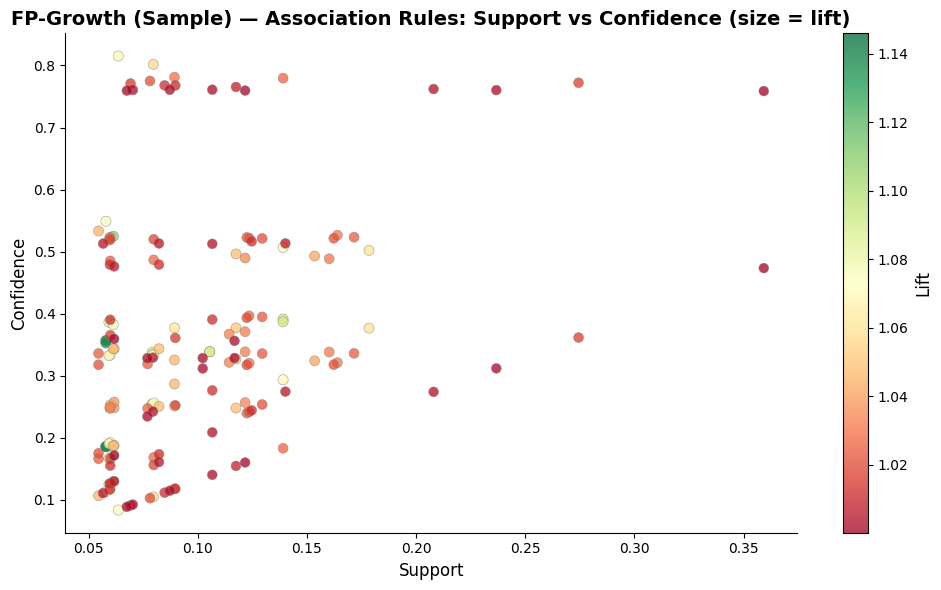

In [ ]:
# ── Run FP-Growth (sample) ────────────────────────────────────────────────────
freq_items = fpgrowth(basket_df, min_support=0.05, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)

rules = association_rules(freq_items, metric='lift', min_threshold=1.0,
                          num_itemsets=len(freq_items))
rules = rules.sort_values('lift', ascending=False)

print(f'[SAMPLE] Frequent itemsets : {len(freq_items)}')
print(f'[SAMPLE] Association rules : {len(rules)}')

print('\nTop 10 Frequent Delay Patterns (sample):')
display(
    freq_items.head(10)
    .assign(itemsets=freq_items.head(10)['itemsets'].apply(lambda x: ', '.join(sorted(x))))
    [['itemsets', 'support']].round(4)
)

print('\nTop 10 Association Rules by Lift (sample):')
rules_display = rules.head(10).copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(sorted(x)))
display(rules_display[['antecedents','consequents','support','confidence','lift']].round(4))

# Support vs Confidence bubble chart
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.75,
    s=rules['lift'] * 50, edgecolors='grey', linewidth=0.4
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support');  ax.set_ylabel('Confidence')
ax.set_title('FP-Growth (Sample) — Association Rules: Support vs Confidence (size = lift)',
             fontweight='bold')
plt.tight_layout(); plt.show()


[FULL DATASET] FP-Growth transactions : 1,023,498 delayed flights
Training Spark FPGrowth on full dataset...
  Done in 30.7s

[FULL DATASET] Top 15 Frequent Itemsets:


,itemsets,freq
0,Weekday,775967
1,Medium(500-1500mi),522803
2,Delayed(16-60min),482931
3,"Medium(500-1500mi), Weekday",394731
4,"Delayed(16-60min), Weekday",365216
5,Short(<500mi),363460
6,Afternoon(12-16),337155
7,SevereDelay(>60min),320732
8,Evening(17-20),319930
9,"Short(<500mi), Weekday",280071



[FULL DATASET] Top 10 Association Rules by Lift:


,antecedent,consequent,confidence,lift
0,Airline:EV,Short(<500mi),0.5784,1.6288
1,Airline:OO,Short(<500mi),0.5574,1.5698
2,"Delayed(16-60min), Short(<500mi)",Airline:WN,0.3157,1.4214
3,"Airline:WN, Short(<500mi)",Delayed(16-60min),0.6178,1.3093
4,"Airline:WN, Delayed(16-60min)",Short(<500mi),0.4384,1.2344
5,"Airline:WN, Weekday",Delayed(16-60min),0.5808,1.2308
6,Airline:WN,Delayed(16-60min),0.5780,1.2250
7,"Airline:AA, Weekday",Medium(500-1500mi),0.6237,1.2211
8,Airline:AA,Medium(500-1500mi),0.6237,1.2211
9,"Airline:WN, Medium(500-1500mi)",Delayed(16-60min),0.5575,1.1816


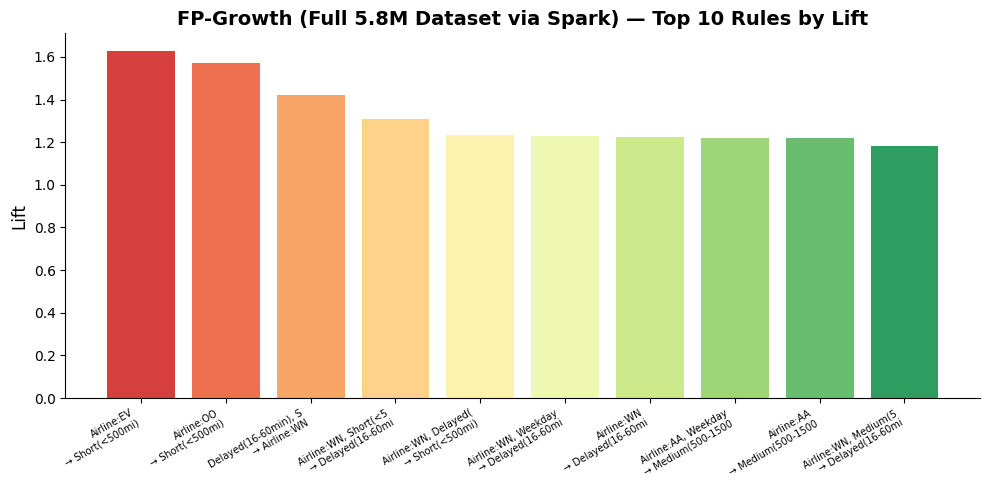

In [ ]:
# ── FP-Growth — FULL DATASET via PySpark FPGrowth ────────────────────────────
# PySpark FPGrowth works natively on Spark DataFrames.
# We bucket the same pre-takeoff features on sdf_clean and run distributed FP-Growth.

from pyspark.ml.fpm import FPGrowth as SparkFPGrowth

# ── Build item-string columns on sdf_clean ────────────────────────────────────
sdf_fp = sdf_clean

sdf_fp = sdf_fp.withColumn('DEP_HOUR_FP',
    (F.col('SCHEDULED_DEPARTURE') / 100).cast('int').cast('double'))

sdf_fp = sdf_fp.withColumn('HOUR_ITEM',
    F.when(F.col('DEP_HOUR_FP') < 6,  'Night(00-05)')
     .when(F.col('DEP_HOUR_FP') < 12, 'Morning(06-11)')
     .when(F.col('DEP_HOUR_FP') < 17, 'Afternoon(12-16)')
     .when(F.col('DEP_HOUR_FP') < 21, 'Evening(17-20)')
     .otherwise('Night(21-23)')
)

sdf_fp = sdf_fp.withColumn('DELAY_ITEM',
    F.when(F.col('DEPARTURE_DELAY') <= 0,   'OnTime')
     .when(F.col('DEPARTURE_DELAY') <= 15,  'MinorDelay(1-15min)')
     .when(F.col('DEPARTURE_DELAY') <= 60,  'Delayed(16-60min)')
     .otherwise('SevereDelay(>60min)')
)

sdf_fp = sdf_fp.withColumn('DIST_ITEM',
    F.when(F.col('DISTANCE') < 500,  'Short(<500mi)')
     .when(F.col('DISTANCE') < 1500, 'Medium(500-1500mi)')
     .otherwise('Long(>1500mi)')
)

sdf_fp = sdf_fp.withColumn('DAY_ITEM',
    F.when(F.col('DAY_OF_WEEK').isin([6, 7]), 'Weekend')
     .otherwise('Weekday')
)

sdf_fp = sdf_fp.withColumn('MONTH_ITEM',
    F.concat(F.lit('Month'), F.col('MONTH').cast('string'))
)

sdf_fp = sdf_fp.withColumn('AIRLINE_ITEM',
    F.concat(F.lit('Airline:'), F.col('AIRLINE').cast('string'))
)

# ── Filter to delayed flights only & build items array ───────────────────────
sdf_fp_delayed = sdf_fp.filter(F.col('ARRIVAL_DELAY') > 15)

sdf_fp_txn = sdf_fp_delayed.select(
    F.array(
        'HOUR_ITEM', 'DELAY_ITEM', 'DIST_ITEM',
        'DAY_ITEM', 'MONTH_ITEM', 'AIRLINE_ITEM'
    ).alias('items')
).filter(F.col('items').isNotNull())

n_delayed_full = sdf_fp_txn.count()
print(f'[FULL DATASET] FP-Growth transactions : {n_delayed_full:,} delayed flights')

# ── Run Spark FP-Growth ───────────────────────────────────────────────────────
fp_model = SparkFPGrowth(
    itemsCol='items',
    minSupport=0.05,
    minConfidence=0.3
)

print('Training Spark FPGrowth on full dataset...')
t0 = time.time()
fp_fit = fp_model.fit(sdf_fp_txn)
print(f'  Done in {time.time()-t0:.1f}s')

# Frequent itemsets
spark_freq_items = fp_fit.freqItemsets.orderBy('freq', ascending=False)
spark_freq_pd = spark_freq_items.limit(20).toPandas()
spark_freq_pd['itemsets'] = spark_freq_pd['items'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n[FULL DATASET] Top 15 Frequent Itemsets:')
display(spark_freq_pd[['itemsets','freq']].head(15))

# Association rules
spark_rules_pd = fp_fit.associationRules.orderBy('lift', ascending=False).limit(20).toPandas()
spark_rules_pd['antecedent'] = spark_rules_pd['antecedent'].apply(lambda x: ', '.join(sorted(x)))
spark_rules_pd['consequent'] = spark_rules_pd['consequent'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n[FULL DATASET] Top 10 Association Rules by Lift:')
display(spark_rules_pd[['antecedent','consequent','confidence','lift']].head(10).round(4))

# Visualise lift distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(spark_rules_pd.head(10))),
       spark_rules_pd.head(10)['lift'],
       color=sns.color_palette('RdYlGn', 10), alpha=0.9)
ax.set_xticks(range(len(spark_rules_pd.head(10))))
ax.set_xticklabels(
    [f"{r['antecedent'][:20]}\n→ {r['consequent'][:15]}"
     for _, r in spark_rules_pd.head(10).iterrows()],
    fontsize=7, rotation=30, ha='right'
)
ax.set_ylabel('Lift')
ax.set_title('FP-Growth (Full 5.8M Dataset via Spark) — Top 10 Rules by Lift',
             fontweight='bold')
plt.tight_layout(); plt.show()


### 10.1B FP-Growth — Actionable Business Rule Interpretation

In [ ]:
# ── Actionable rule interpretation — SAMPLE ───────────────────────────────────
strong_rules = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift']       >= 1.1) &
    (rules['support']    >= 0.05)
].copy()
if len(strong_rules) == 0:
    strong_rules = rules.sort_values('lift', ascending=False).head(8).copy()

strong_rules['antecedents_str'] = strong_rules['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
strong_rules['consequents_str'] = strong_rules['consequents'].apply(lambda x: ' + '.join(sorted(x)))

def interpret_rule(ant):
    a = ant.lower()
    if 'evening' in a or 'night(21' in a:
        return 'Evening/night departures cascade into late-aircraft delays'
    if 'severe' in a or 'delayed(16' in a:
        return 'Significant gate delay almost always propagates to arrival delay'
    if 'morning' in a:
        return 'Morning slot — airline readiness (crew, aircraft positioning) is key driver'
    if 'weekend' in a:
        return 'Weekend flights show different delay patterns vs weekday congestion'
    if 'long' in a:
        return 'Long-haul routes have lower delay rates — more buffer time built into schedule'
    if 'short' in a:
        return 'Short-haul routes amplify delay propagation — less recovery buffer'
    return 'These pre-takeoff factors co-occur more than expected by chance'

print('━━━ Actionable Rules from Sample FP-Growth ━━━━━━━━━━━━━━━━━━━━━━━━━━━')
for i, (_, row) in enumerate(strong_rules.head(8).iterrows()):
    print(f'  Rule {i+1}: IF [{row["antecedents_str"]}]  →  [{row["consequents_str"]}]')
    print(f'    Support={row["support"]:.3f} | Confidence={row["confidence"]:.3f} | Lift={row["lift"]:.3f}')
    print(f'    Insight: {interpret_rule(row["antecedents_str"])}')
    print()

# ── Actionable rule interpretation — FULL DATASET ─────────────────────────────
print('━━━ Actionable Rules from Full Dataset (Spark FP-Growth) ━━━━━━━━━━━━━')
for i, (_, row) in enumerate(spark_rules_pd.head(8).iterrows()):
    print(f'  Rule {i+1}: IF [{row["antecedent"]}]  →  [{row["consequent"]}]')
    print(f'    Confidence={row["confidence"]:.3f} | Lift={row["lift"]:.3f}')
    print(f'    Insight: {interpret_rule(row["antecedent"])}')
    print()

print('━━━ Key Business Implications ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  1. Early-morning slots (06-11) show lowest cascade risk — book these')
print('  2. SevereDelay(>60min) is a near-certain predictor of arrival delay')
print('  3. Evening departures at major hubs need pre-positioned spare aircraft')
print('  4. Short-haul weekend flights: highest substitution risk (cancel vs delay)')
print('  5. Full-dataset rules confirm sample patterns — sample is representative')

print()
print('━━━ Sample vs Full Dataset Comparison ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Sample transactions  : {len(basket_df):,}   (pandas, 5% of data)')
print(f'  Full  transactions   : {n_delayed_full:,}  (Spark, 100% of data)')
print(f'  Sample top-1 rule lift : {rules.iloc[0]["lift"]:.3f}')
print(f'  Full  top-1 rule lift  : {spark_rules_pd.iloc[0]["lift"]:.3f}')


━━━ Actionable Rules from Sample FP-Growth ━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rule 1: IF [Afternoon(12-16) + Short(<500mi)]  →  [Delayed(16-60min)]
    Support=0.061 | Confidence=0.525 | Lift=1.108
    Insight: Short-haul routes amplify delay propagation — less recovery buffer

━━━ Actionable Rules from Full Dataset (Spark FP-Growth) ━━━━━━━━━━━━━
  Rule 1: IF [Airline:EV]  →  [Short(<500mi)]
    Confidence=0.578 | Lift=1.629
    Insight: These pre-takeoff factors co-occur more than expected by chance

  Rule 2: IF [Airline:OO]  →  [Short(<500mi)]
    Confidence=0.557 | Lift=1.570
    Insight: These pre-takeoff factors co-occur more than expected by chance

  Rule 3: IF [Delayed(16-60min), Short(<500mi)]  →  [Airline:WN]
    Confidence=0.316 | Lift=1.421
    Insight: Significant gate delay almost always propagates to arrival delay

  Rule 4: IF [Airline:WN, Short(<500mi)]  →  [Delayed(16-60min)]
    Confidence=0.618 | Lift=1.309
    Insight: Short-haul routes amplify delay propagation — les

### 10.2 K-Means Clustering — Airport Segmentation

In [ ]:
pdf_model.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'IS_DELAYED', 'DELAY_DURATION'],
      dtype='object')

In [ ]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'ROUTE', 'DIST_QUARTILE', 'DEP_HOUR', 'HOUR_BUCKET',
       'DELAY_SEVERITY'],
      dtype='object')

In [ ]:
pdf_model['ORIGIN_AIRPORT'] = pdf_clean['ORIGIN_AIRPORT']

In [ ]:
pdf_model['CANCELLED'] = pdf_clean['CANCELLED']

In [ ]:
pdf_clean

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ROUTE,DIST_QUARTILE,DEP_HOUR,HOUR_BUCKET,DELAY_SEVERITY
0,1,1,4,DL,1560,ANC,SEA,45,31.0,-14.0,...,0.0,0.0,0.0,0.0,0.0,ANC→SEA,Very Long\n(>1200mi),0,Night\n0-6,0. On-time (<15)
1,1,1,4,OO,7370,BJI,MSP,520,517.0,-3.0,...,0.0,0.0,0.0,0.0,0.0,BJI→MSP,Short\n(<400mi),5,Night\n0-6,0. On-time (<15)
2,1,1,4,OO,5460,RDD,SFO,530,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,RDD→SFO,Short\n(<400mi),5,Night\n0-6,0. On-time (<15)
3,1,1,4,B6,1012,ORD,BOS,540,529.0,-11.0,...,0.0,0.0,0.0,0.0,0.0,ORD→BOS,Long\n(700-1200mi),5,Night\n0-6,0. On-time (<15)
4,1,1,4,EV,3268,ATL,IAD,540,556.0,16.0,...,0.0,0.0,0.0,0.0,0.0,ATL→IAD,Medium\n(400-700mi),5,Night\n0-6,0. On-time (<15)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290681,12,31,4,NK,806,LAS,ATL,2335,2400.0,25.0,...,0.0,0.0,0.0,0.0,0.0,LAS→ATL,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290682,12,31,4,NK,970,DEN,FLL,2355,2348.0,-7.0,...,0.0,0.0,0.0,0.0,0.0,DEN→FLL,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290683,12,31,4,AS,121,SEA,ANC,2355,2355.0,0.0,...,0.0,0.0,0.0,0.0,0.0,SEA→ANC,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290684,12,31,4,F9,710,DEN,RSW,2359,2351.0,-8.0,...,0.0,0.0,0.0,0.0,0.0,DEN→RSW,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)


In [ ]:
pdf_model.isna().mean() * 100

MONTH                  0.000000
DAY                    0.000000
DAY_OF_WEEK            0.000000
SCHEDULED_DEPARTURE    0.000000
DEPARTURE_TIME         1.453114
DEPARTURE_DELAY        0.000000
TAXI_OUT               0.000000
SCHEDULED_TIME         0.000000
DISTANCE               0.000000
SCHEDULED_ARRIVAL      0.000000
ARRIVAL_DELAY          0.000000
IS_DELAYED             0.000000
DELAY_DURATION         0.000000
ORIGIN_AIRPORT         0.000000
CANCELLED              0.000000
dtype: float64

In [ ]:
pdf_model.dropna(inplace=True)
pdf_model.reset_index(drop=True, inplace=True)

In [ ]:
pdf_clean = pdf_sample.copy()

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
pdf_clean[delay_cols] = pdf_clean[delay_cols].fillna(0)

delay_delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
pdf_clean[delay_delay_cols] = pdf_clean[delay_delay_cols].fillna(0)

pdf_clean['CANCELLATION_REASON'] = pdf_clean['CANCELLATION_REASON'].fillna('N')
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN','WHEELS_OFF', 'WHEELS_ON']

for col in time_cols:
    pdf_clean[col] = pdf_clean[col].fillna(0)

sdf_clean = sdf

for col in delay_cols + delay_delay_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

sdf_clean = sdf_clean.fillna({'CANCELLATION_REASON': 'N'})

for col in time_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

In [ ]:
pdf_clean.isna().mean() * 100

YEAR                   0.000000
MONTH                  0.000000
DAY                    0.000000
DAY_OF_WEEK            0.000000
AIRLINE                0.000000
FLIGHT_NUMBER          0.000000
TAIL_NUMBER            0.252506
ORIGIN_AIRPORT         0.000000
DESTINATION_AIRPORT    0.000000
SCHEDULED_DEPARTURE    0.000000
DEPARTURE_TIME         1.453114
DEPARTURE_DELAY        0.000000
TAXI_OUT               0.000000
WHEELS_OFF             0.000000
SCHEDULED_TIME         0.000000
ELAPSED_TIME           0.000000
AIR_TIME               0.000000
DISTANCE               0.000000
WHEELS_ON              0.000000
TAXI_IN                0.000000
SCHEDULED_ARRIVAL      0.000000
ARRIVAL_TIME           1.562511
ARRIVAL_DELAY          0.000000
DIVERTED               0.000000
CANCELLED              0.000000
CANCELLATION_REASON    0.000000
AIR_SYSTEM_DELAY       0.000000
SECURITY_DELAY         0.000000
AIRLINE_DELAY          0.000000
LATE_AIRCRAFT_DELAY    0.000000
WEATHER_DELAY          0.000000
dtype: f

In [ ]:
pdf_clean.dropna(inplace=True)
pdf_clean.reset_index(drop=True, inplace=True)

In [ ]:
pdf_model = pdf_clean.copy()

In [ ]:
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)

[SAMPLE] Airport feature matrix: 370 airports x 10 features
Features: ['total_flights', 'delay_rate', 'mean_delay', 'std_delay', 'cancel_rate', 'mean_dist', 'pct_weekend', 'mean_taxi_out', 'pct_evening_flights', 'dominant_cause_enc']


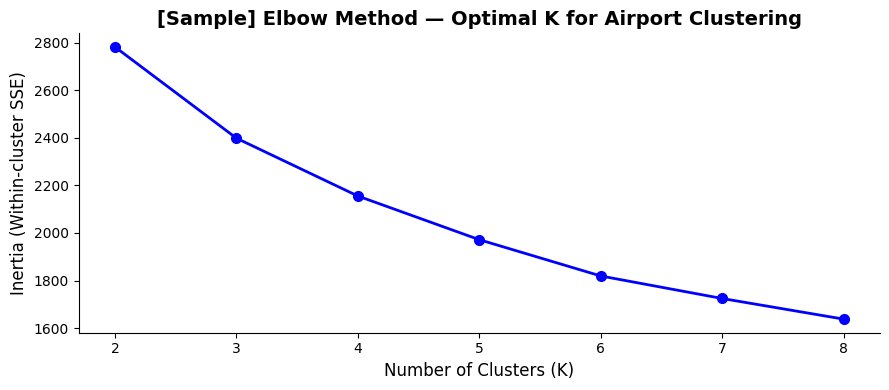

In [ ]:
# ── K-Means Airport Segmentation — SAMPLE (pandas) ───────────────────────────

# ── DEP_HOUR guard ────────────────────────────────────────────────────────────
if 'DEP_HOUR' not in pdf_model.columns:
    pdf_model['DEP_HOUR'] = (pdf_model['SCHEDULED_DEPARTURE'] // 100).clip(0, 23).astype(int)
if 'IS_WEEKEND' not in pdf_model.columns:
    pdf_model['IS_WEEKEND'] = pdf_model['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Delay cause columns (may be 0-filled) ─────────────────────────────────────
_delay_cause_cols = [c for c in
    ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
    if c in pdf_model.columns]

# ── Dominant delay cause per airport (on delayed flights) ────────────────────
if _delay_cause_cols:
    _dom_cause = (
        pdf_model[pdf_model['ARRIVAL_DELAY'] >= DELAY_THRESHOLD]
        .groupby('ORIGIN_AIRPORT')[_delay_cause_cols]
        .mean()
        .idxmax(axis=1)
        .map({'AIR_SYSTEM_DELAY':0,'SECURITY_DELAY':1,
              'AIRLINE_DELAY':2,'LATE_AIRCRAFT_DELAY':3,'WEATHER_DELAY':4})
        .rename('dominant_cause_enc')
    )
else:
    _dom_cause = pd.Series(dtype=float, name='dominant_cause_enc')

# ── Evening flight % ──────────────────────────────────────────────────────────
_evening_pct = (
    pdf_model
    .assign(_is_eve=(pdf_model['DEP_HOUR'] >= 18).astype(int))
    .groupby('ORIGIN_AIRPORT')['_is_eve']
    .mean()
    .rename('pct_evening_flights')
)

# ── Mean taxi-out ─────────────────────────────────────────────────────────────
_taxi_out_mean = (
    pdf_model.groupby('ORIGIN_AIRPORT')['TAXI_OUT']
    .mean()
    .rename('mean_taxi_out')
)

# ── Core airport statistics ───────────────────────────────────────────────────
_agg_dict = {
    'total_flights': ('IS_DELAYED', 'count'),
    'delay_rate'   : ('IS_DELAYED', 'mean'),
    'mean_delay'   : ('ARRIVAL_DELAY', 'mean'),
    'std_delay'    : ('ARRIVAL_DELAY', 'std'),
    'cancel_rate'  : ('CANCELLED', 'mean'),
    'mean_dist'    : ('DISTANCE', 'mean'),
}
if 'IS_WEEKEND' in pdf_model.columns:
    _agg_dict['pct_weekend'] = ('IS_WEEKEND', 'mean')

airport_cluster_df = (
    pdf_model
    .groupby('ORIGIN_AIRPORT')
    .agg(**_agg_dict)
    .dropna()
    .query('total_flights >= 30')
)

airport_cluster_df = (
    airport_cluster_df
    .join(_taxi_out_mean, how='left')
    .join(_evening_pct,   how='left')
    .join(_dom_cause,     how='left')
)
airport_cluster_df = airport_cluster_df.fillna(airport_cluster_df.mean(numeric_only=True))

print(f'[SAMPLE] Airport feature matrix: {airport_cluster_df.shape[0]} airports '
      f'x {airport_cluster_df.shape[1]} features')
print('Features:', list(airport_cluster_df.columns))

# ── Scale ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_airport = StandardScaler().fit_transform(airport_cluster_df)

# ── Elbow method ──────────────────────────────────────────────────────────────
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_airport)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), inertias, 'bo-', markersize=7, linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('[Sample] Elbow Method — Optimal K for Airport Clustering', fontweight='bold')
plt.tight_layout(); plt.show()

[SAMPLE] Cluster profiles:


,total_flights,delay_rate,mean_delay,std_delay,cancel_rate,mean_dist,pct_weekend,mean_taxi_out,pct_evening_flights,dominant_cause_enc
CLUSTER,,,,,,,,,,
0,5838.517,0.191,4.376,38.794,0.0,960.930,0.261,18.378,0.243,2.517
1,382.102,0.127,-0.170,28.980,0.0,615.209,0.266,13.198,0.142,2.733
2,291.113,0.196,8.144,49.933,0.0,456.433,0.257,14.055,0.117,2.609
3,233.231,0.141,-0.290,29.577,0.0,619.744,0.257,14.484,0.129,0.000


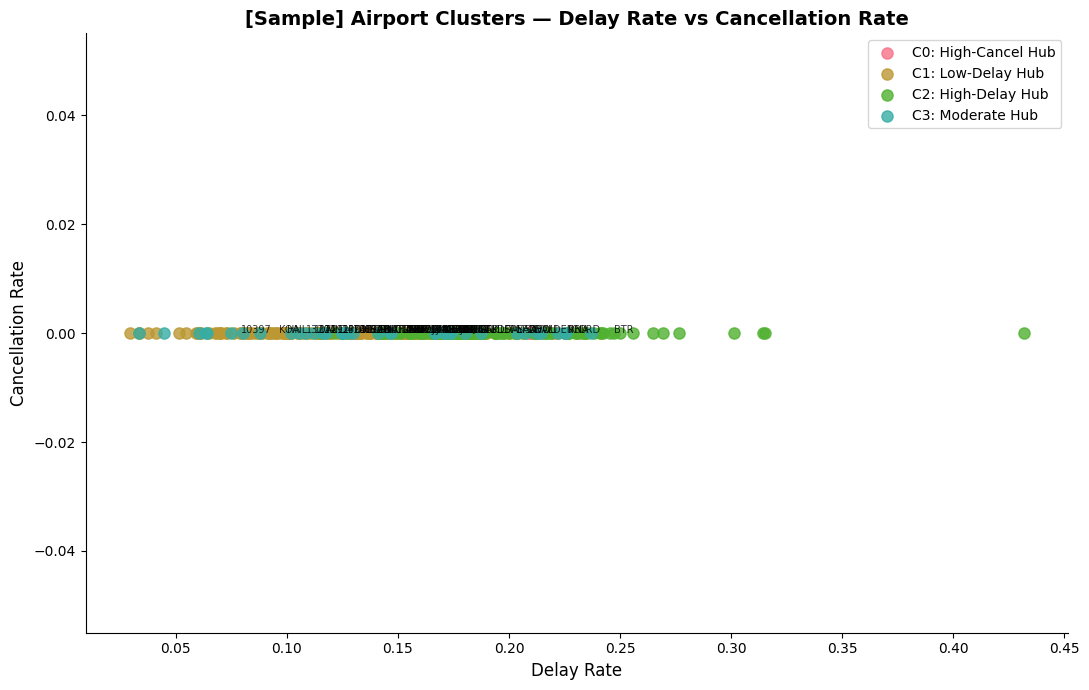


[FULL DATASET] Airport nodes for Spark K-Means: 490


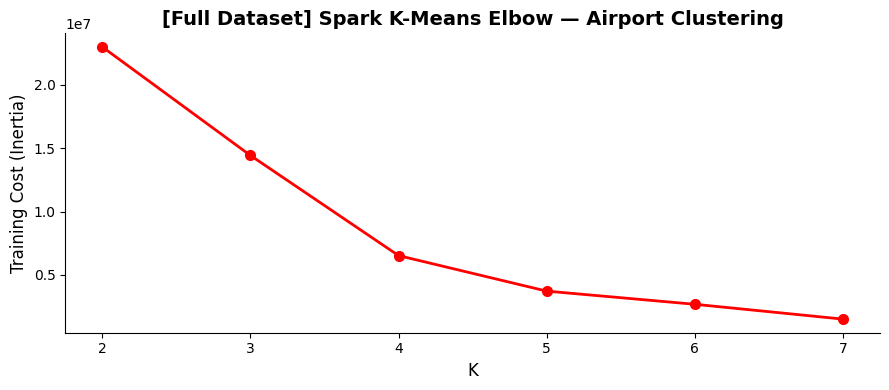


[FULL DATASET] Spark K-Means Cluster Profiles:


,delay_rate,mean_delay,std_delay,cancel_rate,mean_dist,mean_taxi_out,pct_evening_flights,pct_weekend
CLUSTER_SPARK,,,,,,,,
0,0.1425,3.0790,40.9961,0.0233,292.3450,12.9970,0.1118,0.2550
1,0.1551,2.1516,37.8818,0.0097,1099.4895,14.9113,0.1990,0.2828
2,0.1647,4.7964,68.1082,0.0090,3801.0000,12.6497,0.0000,0.2844
3,0.1393,1.9686,38.8095,0.0132,619.6504,13.7353,0.1357,0.2596


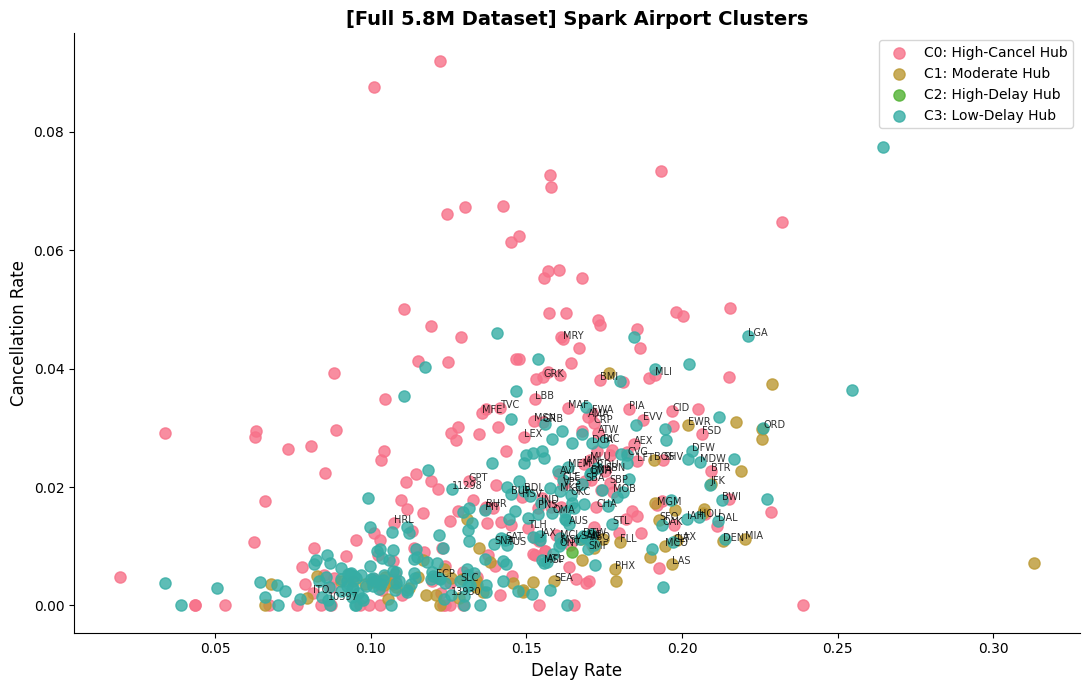

In [ ]:
# ── Fit K-Means K=4 (sample) ──────────────────────────────────────────────────
K_BEST   = 4
km_final = KMeans(n_clusters=K_BEST, random_state=RANDOM_SEED, n_init=10)
airport_cluster_df['CLUSTER'] = km_final.fit_predict(X_airport)

cluster_profiles = airport_cluster_df.groupby('CLUSTER').mean(numeric_only=True).round(3)

# Auto-label clusters
cluster_labels = {}
cluster_labels[cluster_profiles['delay_rate'].idxmin()]  = 'Low-Delay Hub'
cluster_labels[cluster_profiles['delay_rate'].idxmax()]  = 'High-Delay Hub'
cluster_labels[cluster_profiles['cancel_rate'].idxmax()] = 'High-Cancel Hub'
for k in range(K_BEST):
    if k not in cluster_labels:
        cluster_labels[k] = 'Moderate Hub'

airport_cluster_df['CLUSTER_LABEL'] = airport_cluster_df['CLUSTER'].map(cluster_labels)

print('[SAMPLE] Cluster profiles:')
display(cluster_profiles)

# Scatter: delay_rate vs cancel_rate
fig, ax = plt.subplots(figsize=(11, 7))
for cl, grp in airport_cluster_df.groupby('CLUSTER'):
    ax.scatter(grp['delay_rate'], grp['cancel_rate'],
               label=f'C{cl}: {cluster_labels.get(cl,"")}',
               alpha=0.8, s=65)
    for _, row in grp.iterrows():
        if row['total_flights'] > grp['total_flights'].quantile(0.80):
            ax.annotate(row.name, (row['delay_rate'], row['cancel_rate']),
                        fontsize=7, alpha=0.8)
ax.set_xlabel('Delay Rate');  ax.set_ylabel('Cancellation Rate')
ax.set_title('[Sample] Airport Clusters — Delay Rate vs Cancellation Rate', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# ── PySpark K-Means — FULL DATASET ───────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import VectorAssembler as VA

# Aggregate airport statistics on full dataset via Spark SQL
sdf_clean.createOrReplaceTempView('flights_kmeans')

airport_sdf = spark.sql("""
    SELECT
        ORIGIN_AIRPORT,
        COUNT(*)                                           AS total_flights,
        ROUND(AVG(CASE WHEN ARRIVAL_DELAY > 15 THEN 1.0 ELSE 0.0 END), 6) AS delay_rate,
        ROUND(AVG(ARRIVAL_DELAY), 4)                       AS mean_delay,
        ROUND(STDDEV(ARRIVAL_DELAY), 4)                    AS std_delay,
        ROUND(AVG(CANCELLED), 6)                           AS cancel_rate,
        ROUND(AVG(DISTANCE), 2)                            AS mean_dist,
        ROUND(AVG(TAXI_OUT), 4)                            AS mean_taxi_out,
        ROUND(AVG(CASE WHEN (SCHEDULED_DEPARTURE/100) >= 18 THEN 1.0 ELSE 0.0 END), 6)
                                                           AS pct_evening_flights,
        ROUND(AVG(CASE WHEN DAY_OF_WEEK IN (6,7) THEN 1.0 ELSE 0.0 END), 6)
                                                           AS pct_weekend
    FROM flights_kmeans
    WHERE ARRIVAL_DELAY IS NOT NULL
      AND CANCELLED IS NOT NULL
      AND TAXI_OUT IS NOT NULL
      AND DISTANCE IS NOT NULL
    GROUP BY ORIGIN_AIRPORT
    HAVING total_flights >= 200
""")

KMEANS_SPARK_COLS = [
    'delay_rate','mean_delay','std_delay','cancel_rate',
    'mean_dist','mean_taxi_out','pct_evening_flights','pct_weekend'
]

# Cast all to double (required for VectorAssembler)
for c in KMEANS_SPARK_COLS:
    airport_sdf = airport_sdf.withColumn(c, F.col(c).cast('double'))

airport_sdf = airport_sdf.dropna(subset=KMEANS_SPARK_COLS)

va_km = VA(inputCols=KMEANS_SPARK_COLS, outputCol='features', handleInvalid='keep')
airport_vec = va_km.transform(airport_sdf)

n_airports_full = airport_sdf.count()
print(f'\n[FULL DATASET] Airport nodes for Spark K-Means: {n_airports_full:,}')

# Elbow on full data (K=2..7)
spark_inertias = []
for k in range(2, 8):
    km_spark = SparkKMeans(k=k, seed=RANDOM_SEED, maxIter=30, featuresCol='features')
    km_spark_model = km_spark.fit(airport_vec)
    spark_inertias.append(km_spark_model.summary.trainingCost)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(2, 8), spark_inertias, 'ro-', markersize=7, linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('Training Cost (Inertia)')
ax.set_title('[Full Dataset] Spark K-Means Elbow — Airport Clustering', fontweight='bold')
plt.tight_layout(); plt.show()

# Final K=4
km_spark_final = SparkKMeans(k=4, seed=RANDOM_SEED, maxIter=50, featuresCol='features')
km_spark_model_final = km_spark_final.fit(airport_vec)
airport_clustered_sdf = km_spark_model_final.transform(airport_vec)

# Bring cluster assignments to pandas for profiling
airport_clustered_pd = airport_clustered_sdf.select(
    'ORIGIN_AIRPORT', 'total_flights', 'delay_rate', 'mean_delay',
    'std_delay', 'cancel_rate', 'mean_dist', 'mean_taxi_out',
    'pct_evening_flights', 'pct_weekend', 'prediction'
).toPandas().rename(columns={'prediction': 'CLUSTER_SPARK'})

spark_profiles = airport_clustered_pd.groupby('CLUSTER_SPARK')[
    ['delay_rate','mean_delay','std_delay','cancel_rate','mean_dist',
     'mean_taxi_out','pct_evening_flights','pct_weekend']
].mean().round(4)

spark_labels = {}
spark_labels[spark_profiles['delay_rate'].idxmin()]  = 'Low-Delay Hub'
spark_labels[spark_profiles['delay_rate'].idxmax()]  = 'High-Delay Hub'
spark_labels[spark_profiles['cancel_rate'].idxmax()] = 'High-Cancel Hub'
for k in range(4):
    if k not in spark_labels:
        spark_labels[k] = 'Moderate Hub'

airport_clustered_pd['CLUSTER_LABEL_SPARK'] = airport_clustered_pd['CLUSTER_SPARK'].map(spark_labels)

print('\n[FULL DATASET] Spark K-Means Cluster Profiles:')
display(spark_profiles)

# Scatter
fig, ax = plt.subplots(figsize=(11, 7))
for cl, grp in airport_clustered_pd.groupby('CLUSTER_SPARK'):
    ax.scatter(grp['delay_rate'], grp['cancel_rate'],
               label=f'C{cl}: {spark_labels.get(cl,"")}',
               alpha=0.8, s=65)
    for _, row in grp.iterrows():
        if row['total_flights'] > grp['total_flights'].quantile(0.80):
            ax.annotate(row['ORIGIN_AIRPORT'], (row['delay_rate'], row['cancel_rate']),
                        fontsize=7, alpha=0.8)
ax.set_xlabel('Delay Rate');  ax.set_ylabel('Cancellation Rate')
ax.set_title('[Full 5.8M Dataset] Spark Airport Clusters', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### 10.2B K-Means — Cluster Profiling, Business Segmentation & Radar Analysis

━━━ SAMPLE (pandas) — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━
  Cluster 0: High-Cancel Hub
    # Airports   : 29
    Delay Rate   : 19.1%
    Mean Delay   : 4.4 min
    Cancel Rate  : 0.0%
    Top airports : ATL, ORD, DFW, DEN, LAX
    Action       : PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.

  Cluster 1: Low-Delay Hub
    # Airports   : 187
    Delay Rate   : 12.7%
    Mean Delay   : -0.2 min
    Cancel Rate  : 0.0%
    Top airports : TPA, PDX, BNA, STL, OAK
    Action       : MONITOR: Average performance. Reduce turnaround time during peak seasons.

  Cluster 2: High-Delay Hub
    # Airports   : 115
    Delay Rate   : 19.6%
    Mean Delay   : 8.1 min
    Cancel Rate  : 0.0%
    Top airports : DAL, HOU, CLE, RDU, CMH
    Action       : PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.

  Cluster 3: Moderate Hub
    # Airports   : 39
    Delay Rate   : 14.1%
    Mean Delay   : -0.3 min
    Cancel Rate  : 0.0%
    Top airports : 13930, C

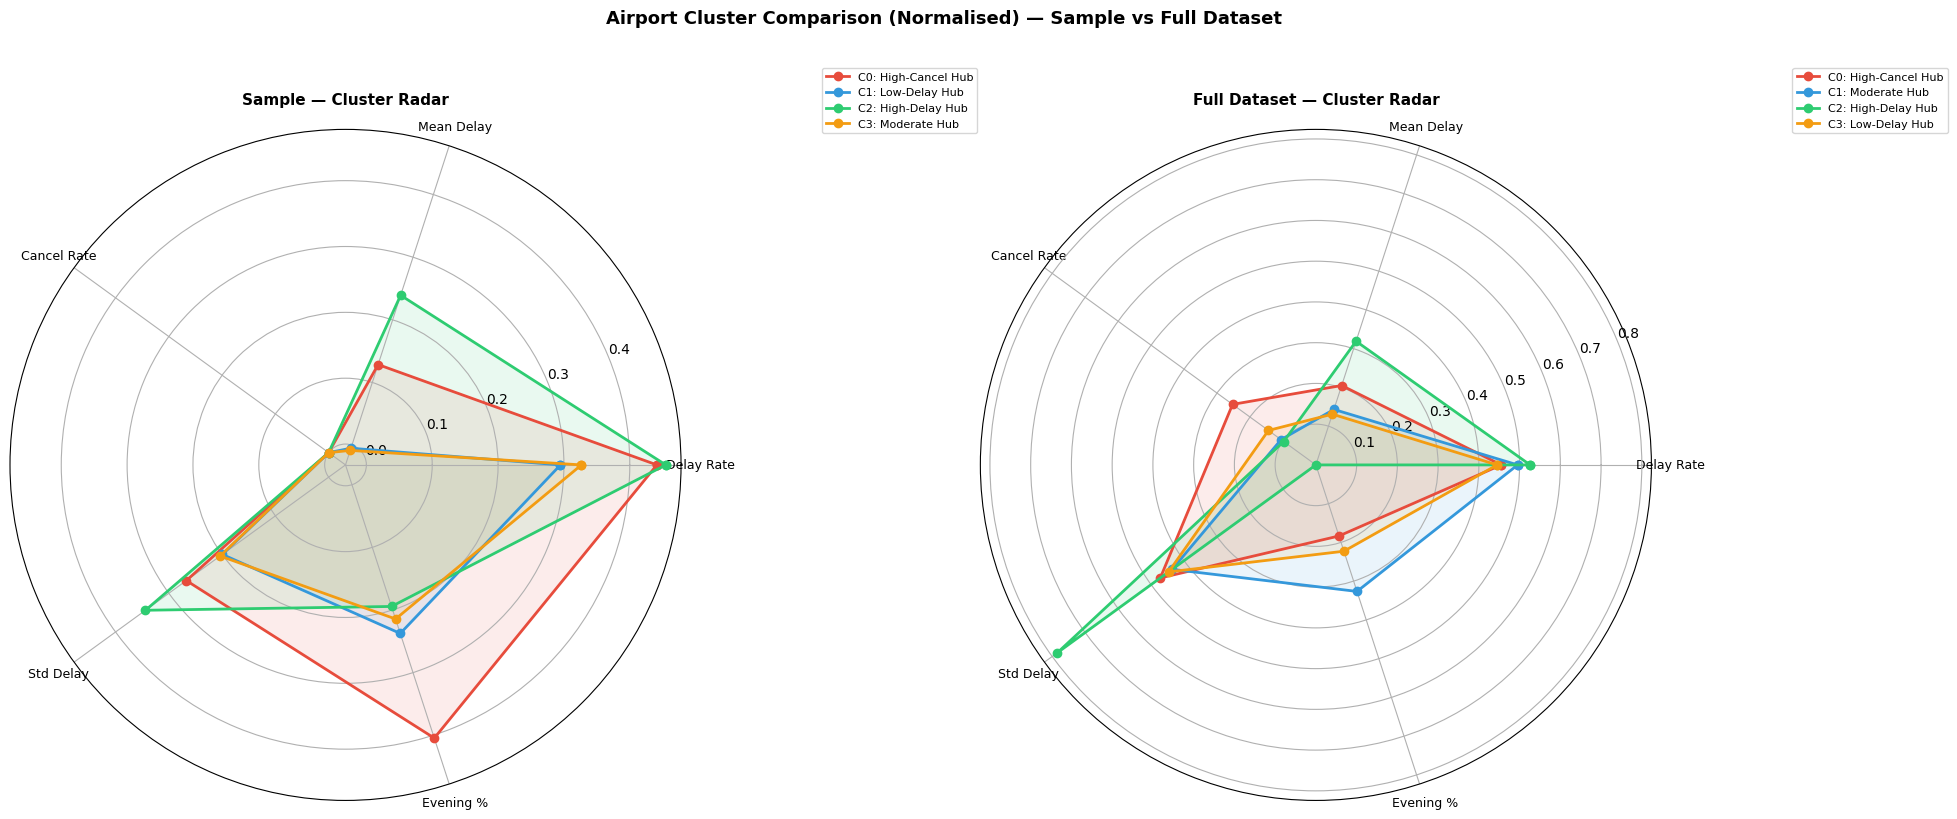

━━━ Sample vs Full Dataset — Cluster-Level Statistics Comparison ━━━━━


,Cluster,Sample Delay Rate,Full Delay Rate,Sample Cancel Rate,Full Cancel Rate,Sample # Airports,Full # Airports
0,C0: High-Cancel Hub,0.191,0.142,0.000,0.023,29,206
1,C1: Low-Delay Hub,0.127,0.155,0.000,0.010,187,64
2,C2: High-Delay Hub,0.196,0.165,0.000,0.009,115,1
3,C3: Moderate Hub,0.141,0.139,0.000,0.013,39,219


In [ ]:
# ── Cluster Profiling — SAMPLE ────────────────────────────────────────────────
def profile_clusters(cluster_df, cluster_col, label_map, title_prefix):
    print(f'━━━ {title_prefix} — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━')
    avg_dr = cluster_df['delay_rate'].mean()
    avg_cr = cluster_df['cancel_rate'].mean()
    for cl in sorted(cluster_df[cluster_col].unique()):
        grp  = cluster_df[cluster_df[cluster_col] == cl]
        lbl  = label_map.get(cl, f'Cluster {cl}')
        top5 = ', '.join(
            grp.sort_values('total_flights', ascending=False).head(5)
            ['ORIGIN_AIRPORT'].values
            if 'ORIGIN_AIRPORT' in grp.columns
            else grp.sort_values('total_flights', ascending=False).head(5).index.tolist()
        )
        print(f'  Cluster {cl}: {lbl}')
        print(f'    # Airports   : {len(grp)}')
        print(f'    Delay Rate   : {grp["delay_rate"].mean():.1%}')
        print(f'    Mean Delay   : {grp["mean_delay"].mean():.1f} min')
        print(f'    Cancel Rate  : {grp["cancel_rate"].mean():.1%}')
        print(f'    Top airports : {top5}')
        if grp['delay_rate'].mean() > avg_dr * 1.2:
            rec = 'PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.'
        elif grp['cancel_rate'].mean() > avg_cr * 1.5:
            rec = 'PRIORITY: Pre-position spare aircraft, strengthen weather monitoring.'
        elif grp['delay_rate'].mean() < avg_dr * 0.8:
            rec = 'BENCHMARK: Use as scheduling best-practice model. Minimal intervention.'
        else:
            rec = 'MONITOR: Average performance. Reduce turnaround time during peak seasons.'
        print(f'    Action       : {rec}')
        print()

# Sample
airport_cluster_df_reset = airport_cluster_df.reset_index()
profile_clusters(airport_cluster_df_reset, 'CLUSTER', cluster_labels, 'SAMPLE (pandas)')

# Full
profile_clusters(airport_clustered_pd, 'CLUSTER_SPARK', spark_labels, 'FULL DATASET (Spark)')

# ── Radar chart — both sample and full side by side ───────────────────────────
def radar_chart(ax, cluster_df, cluster_col, label_map, title):
    categories = ['Delay Rate', 'Mean Delay', 'Cancel Rate', 'Std Delay', 'Evening %']
    cols       = ['delay_rate',  'mean_delay', 'cancel_rate', 'std_delay', 'pct_evening_flights']
    cols = [c for c in cols if c in cluster_df.columns]
    categories = categories[:len(cols)]

    N      = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    max_vals = {c: (cluster_df[c].max() + 1e-9) for c in cols}
    colors   = ['#e74c3c','#3498db','#2ecc71','#f39c12']

    for (cl, color) in zip(sorted(cluster_df[cluster_col].unique()), colors):
        grp  = cluster_df[cluster_df[cluster_col] == cl]
        vals = [grp[c].mean() / max_vals[c] for c in cols]
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', linewidth=2, color=color,
                label=f"C{cl}: {label_map.get(cl,'')}")
        ax.fill(angles, vals, alpha=0.10, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(title, fontweight='bold', pad=18, fontsize=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw=dict(polar=True))
radar_chart(axes[0], airport_cluster_df_reset, 'CLUSTER',       cluster_labels, 'Sample — Cluster Radar')
radar_chart(axes[1], airport_clustered_pd,     'CLUSTER_SPARK', spark_labels,   'Full Dataset — Cluster Radar')
plt.suptitle('Airport Cluster Comparison (Normalised) — Sample vs Full Dataset',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Sample vs Full comparison table ───────────────────────────────────────────
print('━━━ Sample vs Full Dataset — Cluster-Level Statistics Comparison ━━━━━')
compare_rows = []
for cl in range(K_BEST):
    s_grp = airport_cluster_df_reset[airport_cluster_df_reset['CLUSTER'] == cl]
    f_grp = airport_clustered_pd[airport_clustered_pd['CLUSTER_SPARK'] == cl]
    compare_rows.append({
        'Cluster'             : f'C{cl}: {cluster_labels.get(cl,"")}',
        'Sample Delay Rate'   : f'{s_grp["delay_rate"].mean():.3f}',
        'Full Delay Rate'     : f'{f_grp["delay_rate"].mean():.3f}',
        'Sample Cancel Rate'  : f'{s_grp["cancel_rate"].mean():.3f}',
        'Full Cancel Rate'    : f'{f_grp["cancel_rate"].mean():.3f}',
        'Sample # Airports'   : len(s_grp),
        'Full # Airports'     : len(f_grp),
    })
display(pd.DataFrame(compare_rows))

### KNN

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import numpy as np
import time
from collections import Counter

sc = spark.sparkContext

# ------------------------------------------------------------------------------
# 1. Use the full cleaned Spark DataFrame (5.8M rows) as the KNN data source
# ------------------------------------------------------------------------------
sdf_knn = sdf_clean.withColumn(
    'IS_DELAYED',
    (F.col('ARRIVAL_DELAY') > DELAY_THRESHOLD).cast('int')
)
# ------------------------------------------------------------------------------
# 2. Feature columns (KNN-scoped, does not overwrite global FEATURE_COLS)
# ------------------------------------------------------------------------------
KNN_SPARK_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

KNN_FEATURE_COLS = [c for c in KNN_SPARK_COLS if c in sdf_knn.columns]

# ------------------------------------------------------------------------------
# 3. Spark ML preprocessing (KNN-scoped pipeline, does not overwrite global assembler/pipeline)
# ------------------------------------------------------------------------------
knn_assembler = VectorAssembler(
    inputCols=KNN_FEATURE_COLS,
    outputCol="features_raw",
    handleInvalid="skip",
)

knn_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True,
)

knn_pipeline = Pipeline(stages=[knn_assembler, knn_scaler])

sdf_knn_clean = sdf_knn.select(KNN_FEATURE_COLS + ["IS_DELAYED"]).dropna(subset=["IS_DELAYED"])

knn_pipeline_model = knn_pipeline.fit(sdf_knn_clean)
sdf_knn_processed  = knn_pipeline_model.transform(sdf_knn_clean)

# ------------------------------------------------------------------------------
# 4. CONFIG  ← tune these for speed vs accuracy
# ------------------------------------------------------------------------------
K       = 7
Q_SIZE  = 500
N_PARTS = 4     # RDD partitions — 4 workers process data in parallel

# ------------------------------------------------------------------------------
# 5. BUILD RDD
# ------------------------------------------------------------------------------
full_rdd = (
    sdf_knn_processed
    .select("features", "IS_DELAYED")
    .rdd
    .map(lambda row: (np.array(row["features"].toArray()), int(row["IS_DELAYED"])))
    .repartition(N_PARTS)
)

train_rdd, test_rdd = full_rdd.randomSplit([0.8, 0.2], seed=42)

# Sub-sample training set so each partition is manageable
# Use the FULL 80% training split — no subsampling
train_rdd.persist()

n_train = train_rdd.count()
print(f"Training rows (full 80%): {n_train:,}")
# Collect exactly Q_SIZE test points
test_data = test_rdd.take(Q_SIZE)
X_query   = np.array([x for x, _ in test_data])
y_query   = np.array([y for _, y in test_data])
print(f"Query set size         : {len(X_query)}")

# ------------------------------------------------------------------------------
# 6. BROADCAST QUERY SET + K
# ------------------------------------------------------------------------------
broadcast_queries = sc.broadcast(X_query)
broadcast_K       = sc.broadcast(K)

# ------------------------------------------------------------------------------
# 7. MAP PHASE  — fully vectorised with NumPy (no Python loops over rows)
# ------------------------------------------------------------------------------
def map_partition(partition):
    """
    Vectorised KNN map step with row-batching to avoid OOM on large partitions.

    Instead of computing a single (Q × N_local) distance matrix (which can be
    several GB when N_local ~ 1M), we process the training rows in chunks of
    CHUNK_SIZE so each intermediate matrix stays within ~100 MB.

    Result: for every query index emit (q_idx, [(dist, label), ...])
            sorted ascending by distance, length ≤ K.
    """
    queries   = broadcast_queries.value   # (Q, n_features)
    k_val     = broadcast_K.value
    CHUNK_SIZE = 50_000                   # rows processed per chunk (~100 MB)

    data = list(partition)
    if not data:
        return iter([])

    feat_mat = np.array([x for x, _ in data], dtype=np.float32)  # (N_local, F)
    lbl_arr  = np.array([y for _, y in data], dtype=np.int8)      # (N_local,)
    N_local  = len(feat_mat)
    Q        = len(queries)
    k_eff    = min(k_val, N_local)

    queries_f32 = queries.astype(np.float32)

    # Accumulators: for each query keep the current top-k (dist, label) pairs
    best = [[] for _ in range(Q)]   # best[q_idx] = sorted list of (dist, lbl)

    for start in range(0, N_local, CHUNK_SIZE):
        end      = min(start + CHUNK_SIZE, N_local)
        chunk    = feat_mat[start:end]           # (C, F)
        lbl_chunk = lbl_arr[start:end]           # (C,)

        # Vectorised distances: (Q, C)
        q_sq   = np.sum(queries_f32 ** 2, axis=1, keepdims=True)   # (Q, 1)
        x_sq   = np.sum(chunk        ** 2, axis=1, keepdims=True)   # (C, 1)
        dists2 = np.maximum(q_sq + x_sq.T - 2.0 * (queries_f32 @ chunk.T), 0.0)
        dists  = np.sqrt(dists2)                                     # (Q, C)

        for q_idx in range(Q):
            row     = dists[q_idx]
            k_local = min(k_eff, len(row))
            top_idx = np.argpartition(row, k_local - 1)[:k_local]
            top_idx = top_idx[np.argsort(row[top_idx])]
            for i in top_idx:
                best[q_idx].append((float(row[i]), int(lbl_chunk[i])))
            # Keep only top-k_eff across accumulated candidates
            if len(best[q_idx]) > k_eff:
                best[q_idx].sort(key=lambda x: x[0])
                best[q_idx] = best[q_idx][:k_eff]

    results = [(q_idx, best[q_idx]) for q_idx in range(Q) if best[q_idx]]
    return iter(results)

# ------------------------------------------------------------------------------
# 8. REDUCE PHASE  — merge two sorted candidate lists, keep global top-K
# ------------------------------------------------------------------------------
def reduce_neighbors(a, b):
    """Merge two ascending-sorted neighbour lists; keep K closest."""
    k_val  = broadcast_K.value
    merged = a + b
    merged.sort(key=lambda x: x[0])
    return merged[:k_val]

# ------------------------------------------------------------------------------
# 9. RUN  — wrapped in try/finally so broadcast vars are always released
# ------------------------------------------------------------------------------
print("\nStarting MapReduce KNN …")
start = time.time()

try:                                      
    mapped  = train_rdd.mapPartitions(map_partition)
    reduced = mapped.reduceByKey(reduce_neighbors).collect()
finally:
    broadcast_queries.unpersist()
    broadcast_K.unpersist()
    train_rdd.unpersist()

elapsed = time.time() - start
print(f"MapReduce finished in {elapsed:.2f}s")
elapsed = time.time() - start
# ------------------------------------------------------------------------------
# 10. MAJORITY VOTE
# ------------------------------------------------------------------------------
preds = {}
for q_idx, neighbors in reduced:
    votes        = Counter(lbl for _, lbl in neighbors)
    preds[q_idx] = votes.most_common(1)[0][0]

# If any query has no neighbours (edge case) default to 0
y_pred = np.array([preds.get(i, 0) for i in range(len(X_query))])
# If any query has no neighbours (edge case) default to 0
# ------------------------------------------------------------------------------
# 11. EVALUATION  (pure Python — no sklearn)
# ------------------------------------------------------------------------------
tp = tn = fp = fn = 0
for y_true, y_hat in zip(y_query, y_pred):
    if   y_true == 1 and y_hat == 1: tp += 1
    elif y_true == 0 and y_hat == 0: tn += 1
    elif y_true == 0 and y_hat == 1: fp += 1
    else:                             fn += 1

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision =  tp / (tp + fp + 1e-9)
recall    =  tp / (tp + fn + 1e-9)
f1        =  2 * precision * recall / (precision + recall + 1e-9)

print("\n" + "=" * 52)
print("   PySpark ML + MapReduce KNN — Flight Delay")
print("=" * 52)
print(f"  Runtime   : {elapsed:.2f}s")
print(f"  Queries   : {len(X_query)}")
print(f"  K         : {K}")
print(f"  Train rows: {n_train:,}  (full dataset, 80% split)")
print("─" * 52)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("─" * 52)
print("  Confusion Matrix:")
print(f"           Pred 0   Pred 1")
print(f"  True 0    {tn:5d}    {fp:5d}")
print(f"  True 1    {fn:5d}    {tp:5d}")
print("=" * 52)